<img src="images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# Autoregressive (AR) Models for Time Series Analysis

Autoregressive (AR) models are among the most fundamental statistical models for analyzing and forecasting time series. Their central idea is simple: the current value of a time series is modeled as a linear combination of its previous values together with a random innovation. An AR model therefore exploits the temporal dependence that often exists between consecutive observations—for example, today's electricity demand may contain information about tomorrow's demand. Formally, an AR model is characterized by its **lag order $p$**, denoted $\text{AR}(p)$, which specifies how many previous observations are included when modeling the current value.

Despite their simplicity, AR models provide an important foundation for understanding time-series analysis. Their mathematical structure makes the relationship between past and current observations explicit, resulting in models that are relatively easy to estimate, analyze, and interpret. At the same time, this simplicity requires several assumptions about the underlying time series, including **stationarity, stable linear temporal relationships, regularly sampled observations, and white-noise innovations**. Understanding these assumptions, and learning how to assess whether they are reasonable, is essential for determining when an AR model can be applied reliably.

This notebook introduces the formal definition and interpretation of AR models before examining their core assumptions and how these can be investigated in practice. Particular attention is given to fitting AR models using **Ordinary Least Squares (OLS)**. By representing previous observations as lagged features, an $\text{AR}(p)$ model can be formulated as a Linear Regression problem, making the connection between autoregressive modeling and classical regression particularly intuitive. The notebook further considers lag-order selection, forecasting, model evaluation, and residual diagnostics to illustrate that successfully estimating the coefficients is only one part of building a useful time-series model.

Modern machine-learning approaches, including **neural-network-based time-series models**, can achieve substantially stronger forecasting performance in many complex applications, particularly when large datasets, nonlinear relationships, multiple variables, or complicated temporal patterns are involved. Nevertheless, AR models remain highly valuable because they are simple, computationally efficient, and interpretable, provide useful statistical baselines, and make fundamental concepts such as temporal dependence, stationarity, persistence, and forecast uncertainty easier to understand. Moreover, autoregressive modeling forms an essential building block for more sophisticated statistical time-series models such as **ARMA, ARIMA, and SARIMA**, making AR models a natural starting point for developing a deeper understanding of time-series analysis.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
from src.utils.libimports.tsa import *
from src.utils.plotting.tsa import *
from src.utils.data.files import *

#### Download Required Data

Some code examples in this notebook use data that first need to be downloaded by running the code cell below. If this code cell throws any error, please check the configuration file `config.yaml` if the URL for downloading datasets is up to date and matches the one on Github. If not, simply download or pull the latest version from Github.

In [2]:
file_eload, _ = download_dataset("tabular/timeseries/tsa-example-daily-electric-load.csv")

File 'data/datasets/tabular/timeseries/tsa-example-daily-electric-load.csv' already exists (use 'overwrite=True' to overwrite it).


#### Prerequisites

* This notebook assumes a basic understanding of time series analysis, particularly regarding the characteristics of times such as stationarity, stability, trends, cycles, outliers, and structural breaks.
* Familiarity with standard Linear Regression is recommended, since we focus on the Ordinary Least Squares (OLS) method to fit AR models.

---

## Motivating Example

Consider the daily electricity load of a power plant. Analyzing this data as a time series can reveal how electricity demand evolves over time and whether current demand is related to previous days. By identifying patterns such as temporal dependencies, recurring fluctuations, unusual load changes, and periods of high or low demand, time-series analysis can also provide the basis for forecasting future electricity requirements. For example, an autoregressive model can exploit the relationship between recent and future load to produce short-term demand forecasts.

These insights can support meaningful operational and planning decisions. Plant and grid operators can use short-term forecasts to schedule generation capacity, manage reserves, plan maintenance, and reduce the risk of insufficient or excessive generation. Energy traders and utilities may use expected demand to support purchasing, pricing, and dispatch decisions, while management and planners can use longer-term patterns to assess capacity requirements and operational efficiency. Ultimately, better understanding and forecasting of electricity load can contribute to lower operating costs, more efficient resource allocation, and a more reliable electricity supply.

Throughout this notebook, we use a time series representing the daily electricity load of a power plant over a whole year (i.e., $365$ observations) as an example. This time series is provided as `.csv` file, so we first load it into a Pandas DataFrame.

In [3]:
df = pd.read_csv(file_eload)

df.head()

,DATE,LOAD
0,2025-01-01,99.17
1,2025-01-02,99.02
2,2025-01-03,98.37
3,2025-01-04,99.07
4,2025-01-05,99.42


As we discuss in more detail later, Autoregressive (AR) models assume regularly sampled data, meaning that the interval between observations is the same. Since our time series features daily observations, this assumption holds. We can therefore extract the list of values for the electricity load as a $1$-dimensional array and use it in all later examples. We also provide the auxiliary method `plot_time_series()` to plot the data; so let's have a first look.

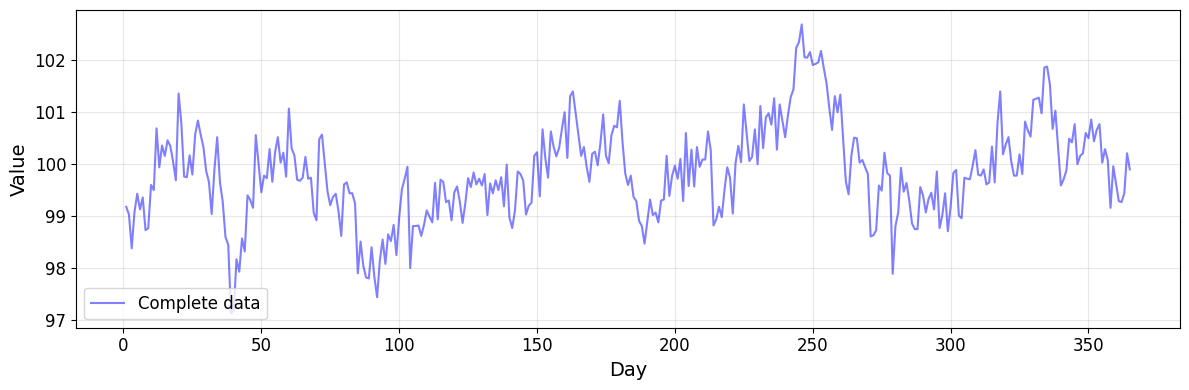

In [4]:
eload = df["LOAD"].to_numpy()

plot_time_series(eload)

Before continuing, just have a look at the data and ask yourself how you would describe this time series. We will see later that AR models cannot handle all kinds of time series but make various assumptions.

**Side note:** The purpose of this dataset is not to gain real-world insights but just to have "some" time series as an example to introduce AR models. In fact, this dataset was synthetically generated to have certain characteristics but also to later assess the performance of AR models fitted on that data. We provide more details on the data generation after covering the basics of AR models.

---

## AR Models &mdash; The Basics

Autoregressive (AR) models are among the most basic statistical models for time series analysis, combining a relatively simple mathematical formulation with an intuitive way of capturing temporal dependencies between observations. However, this simplicity comes at the cost of several assumptions about the structure and statistical properties of the underlying time series. Understanding these assumptions is essential for determining when an AR model is appropriate and for interpreting its results reliably. After a quick recap of time series, this section therefore introduces the mathematical definition of AR models as well as the key assumptions underlying those models and briefly discusses how they can be assessed in practice.

### Quick Recap: Time Series

A time series is a sequence of observations recorded in chronological order, typically at regular intervals such as hourly, daily, or monthly. Unlike ordinary datasets, the ordering of observations matters because values at one point in time may depend on previous observations, creating **temporal dependencies** that can be analyzed and used for forecasting. In its most fundamental form, a time series $\mathcal{S}$ is mathematically most commonly defined as an **ordered sequence of observations indexed by time**, which we can express as:

$$\large
\mathcal{S} = \{x_t\}_{t \in \mathcal{T}},
$$

where $\mathcal{T}$ is the time index set (e.g., ${1,\ldots,T}$, but also $\mathbb{N}$ or $\mathbb{R})$; and $x_t \in \mathcal{X}$ is the observation at time $t$. For a finite discrete time series, which we typically work with in practice, we can express a times series as tuple of observations:

$$\large
\mathbf{x} = (x_1, x_2, \ldots, x_T)
$$

In the context of our example dataset, $x_t$ represents the observed electricity load on day $t$. Since we have the daily observations for a whole year, our time series has the values $(x_1, x_2, \ldots, x_{365})$.

Although more advanced definitions of time series exists &mdash; for example, to explicitly model the time stamps, multiple observations per time stamp, or observations from multiple processes &mdash; basic AR model expects a simple list of individual observations as input, this matching the simple definition above.

**Important:** The notation used for time series observations varies across the literature. Classical textbooks on statistics, econometrics, and state-space models often denote observations by $y_t$. In contrast, contemporary machine learning literature commonly uses $x_t$ to represent observed data, particularly when time series are treated as sequences of input vectors. These choices are purely notational and have no mathematical implications, provided they are used consistently. Throughout this notebook, we adopt the notation $x_t$ for observations, as it aligns with modern machine learning conventions and naturally extends to multivariate time series.

### Model Definition

An autoregressive (AR) model is a **linear model** that assumes the current value of a time series can be expressed as a linear combination of its previous values, plus a random innovation (or shock). In other words, each previous observation contributes proportionally to the current observation through a corresponding coefficient. The model is called *autoregressive* because it uses the time series' own past observations as predictors of its future values.

A basic AR model is fully specified by its **lag order**, denoted by (p), which determines how many previous observations are used to predict the current one. An AR model with lag order (p) is written as $\text{AR}(p)$. For example, an $\text{AR}(p)$ model uses only the immediately preceding observation, whereas an $\text{AR}(p)$ model uses the three most recent observations. Thus, the lag order controls the amount of historical information, or "memory," that the model incorporates when making predictions.

Mathematically, an $\text{AR}(p)$ model is therefore defined as follows:

$$
\begin{align}
\large x_t\ &\large= c + \phi_1 x_{t-1} + \phi_2 x_{t-1} + \cdots + \phi_p x_{t-p} + \varepsilon_t \\[0.75em]
&\large= c + \sum_{i=1}^{p} \phi_i x_{t-i} + \varepsilon_t
\end{align}
$$

where

* $x_i$ is the observation at time step $t$
* $\phi_t$ is the coefficient or weight of observation $x_t$
* $\varepsilon_t$ is the innovation or shock; it captures the new information entering the time series that could not have been predicted from the past observations
* $c$ is a constant to allow for the process to have a non-zero mean

Since AR models are the basis for more advanced models such as ARMA, ARIMA, and SARIMA, let's have a closer look at the purpose and meaning of constant $c$ and innovation $\varepsilon_t$. To this end, we consider the simplest AR model with a lag order of $1$, i.e., $\text{AR}(1)$: 

$$\large 
x_t = c + \phi x_{t-1} + \varepsilon_t
$$

First, let's consider constant $c$ by ignoring it and that the model only relies on past observations and the current innovation:

$$\large 
x_t = \phi x_{t-1} + \varepsilon_t
$$

As we discuss later in more details, AR models assume a (weakly) stationary time series. This means that the expected value for each observation is the same, i.e., $E[x_t] = E[x_{t-1}] = \mu$ and $E[\varepsilon_t] = 0$. This gives us $\mu = \phi\mu$. For any practical purposes, $\phi$ is a non-zero value. This implies that $\mu = 0$. In other words, an AR model without a constant $c$ can only describe processes that fluctuate around zero. In contrast, with constant $c$ ,we get $\mu = c + \phi\mu$, resulting in:

$$\large
\mu = \frac{c}{1 - \phi}
$$

Now the process fluctuates around the mean $\mu$ that is not required to be zero.

The intuition is that the autoregressive term $\phi x_{t-1}$ only determines how deviations from the mean persist over time. It does *not* determine where the process is centered. The constant c shifts the entire process upward or downward by setting its long-run equilibrium level. For example, suppose daily electricity demand averages around 500 MW. An AR model without a constant would predict that demand fluctuates around 0 MW, which is clearly unrealistic. Including a constant allows the model to capture the correct average level while the autoregressive term models the day-to-day deviations around that level.

Recall that the previous expression for $\mu$ was for an $\text{AR}(1)$ model. For a general $\text{AR}(p)$, the mean is:

$$\large
\mu = \frac{c}{1 - \sum_{i=1}^p \phi_i }
$$

To better illustrate the meaning of $\varepsilon_t$, let's assume an observation $x_t$ only depends on previous observations and the constant $c$ to support a non-zero mean. Again assuming a simple $\text{AR}(1)$ model &mdash; although this works with any lag order &mdash; an denote the predicted observation with $\hat{x}_t$, we get:

$$\large 
\hat{x}_t = c + \phi x_{t-1}
$$

Thus, we can express $\varepsilon_t$ as:

$$\large
\varepsilon_t = x_t - \hat{x}_t
$$

This expression clearly shows that $\varepsilon_t$ is the part of observation $x_t$ that could not have been anticipated using any past information. It is literally new information arriving at time $t$, commonly referred to as an **innovation** or **shock**, emphasizing that this unexpected event affects not only the current observation but, through the autoregressive structure, can influence future observations as well.

At first glance, an autoregressive (AR) model closely resembles a Linear Regression model, as both express the target variable as a linear combination of predictors. However, the key difference lies in the choice of predictors. In Linear Regression, the target variable is modeled using one or more **independent features**, whereas in an AR model, the current observation is modeled as a linear combination of its **own previous observations** (lagged values). In other words, an AR model uses the past values of the dependent variable itself as predictors, making it particularly well suited for modeling temporal dependencies in time series data.

We can rewrite the definition of an AR model to explicitly highlight the dependency of an observation on previous observation by a recursive interpretation of AR models. Again, to keep it simple, we consider an $\text{AR}(1)$ model. By substituting $x_{t-1}$ with its own $\text{AR}(1)$ expression, we get:

$$
\begin{aligned}
\large x_t\ &\large= c+\phi x_{t-1}+\varepsilon_t \\[0.5em]
&\large= c+\phi(c+\phi x_{t-2}+\varepsilon_{t-1})+\varepsilon_t \\[0.5em]
&\large= c(1+\phi)+\phi^2 x_{t-2} + \phi\varepsilon_{t-1} +\varepsilon_t
\end{aligned}
$$

Continuing this process &mdash; with the next step replacing $x_{t-2}$ and so one &mdash; will result in:

$$\large
x_t =  \mu + \varepsilon_t + \phi\varepsilon_{t-1} + \phi^2\varepsilon_{t-2} + \cdots
$$

where

$$\large
\mu=\frac{c}{1-\phi}.
$$

as we have already seen above. This expression has an intuitive interpretation. For example, assuming a time series with daily observations, today's value or observation $x_t$ consists of

* the long-run mean $\mu$
* today's innovation $\varepsilon_t$
* yesterday's innovation $\varepsilon_{t-1}$ (partially remembered)
* the innovation from two days ago $\varepsilon_{t-2}$ (remembered even less)
* ...and so on

In other words, the entire time series can be viewed as the accumulation of past innovations. You may already notice that *"partially remembered"* and *"remembered even less"* requires the value of $\phi$ to be less than $1$. This is another of the key assumptions of AR models we discuss next in more detail.

### Core Assumptions

Because AR models are among the simplest models for time series analysis, they rely on several assumptions to accurately capture the underlying temporal dynamics. Verifying these assumptions is therefore an important first step before fitting an AR model, as violations can lead to unreliable parameter estimates and poor forecasting performance. In this section, we briefly outline these core assumption, but a deeper disucssion about how to verify them is beyond the scope here.

**Linear Dependence.** When looking at the model definition of an AR model, the most obvious assumption is that the current observation $x_t$ can be adequately described as a linear combination of previous observations $x_{t-1}$, $x_{t-2}$, ..., $x_{t-p}$. In other words, each lagged observation contributes proportionally to the current value through a fixed coefficient, and these contributions are added together. Consequently, basic AR models are well suited for capturing linear temporal relationships but may fail to accurately model more complex, nonlinear dependencies present in some time series.

The practical challenge is that the assumption of linear dependence cannot be *directly* tested before fitting an AR model. Instead, it is typically assessed by visually inspecting lag plots for approximately linear relationships and, more importantly, by examining the model residuals after fitting. If the residuals exhibit systematic patterns or remaining temporal structure, a linear AR model may not adequately capture the underlying dynamics. In short, linearity is judged based on exploratory analysis and model diagnostics rather than a single formal hypothesis test.

**(Weak) Stationarity.** A time series is weakly (or second-order) stationary if its first and second moments remain constant over time. Specifically, the time series has (1) a constant mean, $E[x_t] = \mu$, (2) a constant finite variance, $\mathrm{Var}(x_t) = \sigma^2$, and (3) an autocovariance that depends only on the time lag between observations, not on their absolute position in time. That is,

$$\large
\mathrm{Cov}(x_t, x_{t+h}) = \gamma(h)
$$

where $\gamma(h)$ is a function only of the lag $h$. Intuitively, this means that the relationship between two observations depends only on how far apart they are in time, not on when they occur. For example, if the autocovariance at a lag of one day is high, then observations one day apart are equally related whether they occur in January, June, or December. Similarly, the relationship between observations one week apart remains the same throughout the entire time series.

The two plots below show a stationary (top) and nonstationary (bottom) time series. The nonstationary time series has a clear upward trend, meaning that the expected value of an observation is not constant. Furthermore, the amplitude of the nonstationary time series increases over time. This, in turn, means that the variance is also not constant.

<img src="images/plots/tsa/tsa-example-stationary-series.png" style="margin:auto;max-width:600px;width:100%" alt="Time Series Example - Stationary Series">
<img src="images/plots/tsa/tsa-example-nonstationary-series.png" style="margin:auto;max-width:600px;width:100%" alt="Time Series Example - Nonstationary Series">

The weak stationarity assumption is typically assessed through a combination of visual inspection and statistical tests. A time series plot can reveal obvious violations such as trends, seasonality, changes in variance, or structural breaks, all of which indicate non-stationarity (see the two example plots above). In addition, formal tests such as the **Augmented Dickey–Fuller (ADF)** test and the **KPSS** test are commonly used to assess stationarity from complementary perspectives: the ADF test has a null hypothesis of a unit root (non-stationarity), whereas the KPSS test assumes stationarity under the null. Since no single test is definitive, stationarity should be evaluated by combining graphical analysis with statistical testing.

**White-Noise Innovations.** The innovations $\varepsilon_t$ of an autoregressive model are assumed to form a white-noise process, meaning they have

* a zero mean $E[\varepsilon_t]$
* a constant variance $Var[\varepsilon_t] = \sigma_\varepsilon^2$
* no autocorrelation, i.e., $\text{Cov}(\varepsilon_t, \varepsilon_{t-k}) = 0 \ \text{for all } k \neq 0$

The last requirement means that innovations are uncorrelated over time, meaning that each innovation represents a new, unpredictable random shock that cannot be inferred from previous innovations or observations.

Note that white noise does not necessarily imply independence. To give an intuitive analogy: Imagine rolling a die every minute and defining the observation as the product of the current roll and the previous roll. Each observation uses a fresh roll, so there is no linear correlation over time. But consecutive observations share one common die roll, meaning they are not completely independent. Information about one observation provides some information about the next.

While AR models only require uncorrelated innovations, many textbooks assume a stricter assumption to include that the innovations are independent and identically distributed (i.i.d.); more formally:

$$\large
\varepsilon_t = \varepsilon_t \overset{\text{i.i.d.}}{\sim} (0,\sigma^2)
$$

Some textbooks go even further and assume that the innovations are also normally distributed:

$$\large
\varepsilon_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma^2)
$$

Again, these are stronger assumptions than white noise and strictly speaking not required for AR models.

The white-noise assumption is verified **after fitting** an AR model by analyzing its residuals, which serve as estimates of the innovations. Residual plots can be used to assess whether the residuals have approximately constant variance and are centered around zero, while the autocorrelation function (ACF) and statistical tests such as the **Ljung–Box test** can be used to detect remaining autocorrelation. If the residuals resemble white noise, the AR model has successfully captured the temporal dependencies in the time series.

**Stability.** The stability assumption states that the effect of past observations and random innovations must **diminish over time**, ensuring that the time series fluctuates around a stable long-run mean rather than diverging or exploding. For an AR(1) model, this is equivalent to requiring that:

$$\large
|\phi| < 1
$$

More generally, for an $\text{AR}(p)$ model, the roots of the characteristic polynomial must lie outside the unit circle.

This assumption is important because it guarantees that the autoregressive process is **stationary** and that the influence of a shock gradually decays rather than persists indefinitely or grows over time. If the stability condition is violated, small random innovations can accumulate or become amplified, causing the process to drift or explode. Consequently, the mean and variance are no longer constant over time, invalidating the assumptions of a classical AR model and leading to unreliable parameter estimates and forecasts.

As such, stability is not an independent assumption from stationarity. Rather, it is the parameter condition that ensures an AR model is stationary. For example, in an AR(1) model, the stationarity assumption translates directly into the requirement $|\phi| < 1$. Because this condition is easy to check after estimating the model, many texts list it separately, even though it is mathematically a consequence of the stationarity assumption rather than an additional one.

**Regular Sampling.** AR models assume that observations are recorded at **regular, equally spaced time intervals** (e.g., hourly, daily, or monthly). This is because the lagged observations used as predictors are defined in terms of a fixed time step. If observations are irregularly spaced, the same lag may correspond to different time intervals, violating the assumptions of the model and potentially leading to misleading parameter estimates and forecasts.

To give an example, the two plots below show two stationary time series observing the same phenomenon, one regularly sampled (top) and one irregularly (bottom). Notice how the overall "look" of both plots is quite different &mdash; at least when using a line plot in case we assume that we can interpolate values between observed time steps.

<img src="images/plots/tsa/tsa-example-stationary-regularly-sampled.png" style="margin:auto;max-width:600px;width:100%" alt="Time Series Example - Regularly Sampled">
<img src="images/plots/tsa/tsa-example-stationary-irregularly-sampled.png" style="margin:auto;max-width:600px;width:100%" alt="Time Series Example - Irregularly Sampled">

**Sufficient Observations.** Like any other machine learning model, AR models require a sufficient number of observations to reliably estimate their parameters. In particular, the number of observations should be substantially larger than the lag order $p$, as each additional lag introduces another coefficient to estimate. If the time series is too short, the estimated coefficients become unstable, increasing the risk of overfitting and reducing the accuracy of forecasts. There is no fixed minimum number of observations required for an AR model. However, the sample size should be substantially larger than the lag order $p$, with a common rule of thumb being at least $10..20$ observations per lagged coefficient. Larger datasets generally lead to more reliable parameter estimates and improved forecasting performance.

**No Structural Breaks.** A **structural break** is a sudden change in the underlying data-generating process of a time series, such as an abrupt shift in its mean, variance, trend, or temporal dependence. Such changes may result from external events, policy changes, equipment replacements, or market disruptions. To give an example, the plot below shows the unemployment rate for a country across a year. Here, the structural break may be caused of a change in the methodology of how unemployment is defined and recorded.

<img src="images/plots/tsa/tsa-example-unemployment-rate.png" style="margin:auto;max-width:850px;width:100%" alt="Time Series Example - Unemployment Rate">

Classical AR models assume that no structural breaks occur, meaning that the same autoregressive relationship remains valid throughout the entire time series.

Although structural breaks inherently violate the assumption of weak stationarity, they are often considered separately because they can be identified and analyzed directly. Visual inspection of the time series may reveal abrupt changes in level or variability, while statistical methods such as the **CUSUM test**, **Chow test** (for known break points), or **Zivot-Andrews test** (for unknown break points) can be used to formally detect structural breaks. Identifying such breaks is important because a single AR model with fixed parameters is generally unable to adequately describe time series whose underlying dynamics change over time.

---

## Fitting an AR Model

Different methods can be used to fit an autoregressive (AR) model; the table below provides an overview of the most common methods together with their key assumptions, as well as their pros and cons. Although they estimate the same underlying AR structure, they approach the estimation problem differently. The choice of method is therefore mainly determined by the following considerations:

* **Main objective:** Methods optimize different quantities. **OLS**, for example, minimizes squared prediction errors, **Yule-Walker** matches the theoretical and observed autocovariance structure, while **MLE** selects the parameters that maximize the probability of observing the available data under an assumed innovation distribution.
* **Trade-off between stability and bias:** Some methods explicitly favor or guarantee stable AR models, potentially at the cost of introducing additional bias. **Burg's method**, for example, produces stable AR estimates, whereas unconstrained OLS may estimate coefficients corresponding to an unstable process, particularly with limited data.
* **Computational and sample sensitivity:** Methods differ in computational complexity and in how strongly their estimates are affected by the amount of available data. **OLS and Yule–Walker** are computationally inexpensive, while exact MLE can require more involved numerical optimization. Similarly, methods such as Burg's method can be attractive for relatively short time series, whereas more complex estimation procedures generally benefit from larger samples.

| Method                                   | Basic idea                                                                                               | Key assumptions                                                                                                                 | Pros                                                                                  | Cons                                                                                                            |
| ---------------------------------------- | -------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------- |
| **Ordinary Least Squares (OLS)**         | Treat lagged observations as predictors and minimize the sum of squared residuals.                       | Standard AR assumptions; Gaussian innovations are **not** required for coefficient estimation.                                  | Simple, fast, intuitive, and easy to implement.                                       | Does not automatically enforce stability; can perform poorly with small samples or high lag orders.             |
| **Yule–Walker**                          | Estimate AR coefficients by matching theoretical autocovariance relationships to sample autocovariances. | Weak stationarity and finite second moments.                                                                                    | Computationally efficient and closely connected to ACF theory.                        | Can be less efficient than MLE and sensitive to sample autocovariance estimates, particularly for short series. |
| **Burg's Method**                        | Estimate coefficients recursively by minimizing both forward and backward prediction errors.             | Stationary AR structure; typically assumes a stable process.                                                                    | Produces stable AR estimates and can perform well for short time series.              | Less intuitive and more complex than OLS or Yule–Walker; more common in signal processing.                      |
| **Conditional MLE**                      | Maximize the likelihood of the observations conditional on the first (p) observations.                   | Requires specifying an innovation distribution, commonly Gaussian.                                                              | Provides a probabilistic framework for estimation and inference.                      | Requires distributional assumptions and does not model the likelihood of the initial observations.              |
| **Exact MLE**                            | Maximize the likelihood of the complete observed series, including the initial observations.             | Requires specifying an innovation distribution and the distribution of the initial observations; commonly assumes stationarity. | Uses all available information and can provide statistically efficient estimates.     | More computationally involved and sensitive to incorrect distributional assumptions.                            |
| **Bayesian Estimation**                  | Combine the likelihood with prior distributions to obtain posterior distributions of the AR parameters.  | Requires specification of priors and a likelihood model.                                                                        | Provides full uncertainty quantification and allows incorporation of prior knowledge. | Computationally expensive and potentially sensitive to prior choices.                                           |
| **Regularized Regression (Ridge/LASSO)** | Fit the AR model as a regression while penalizing the magnitude of the lag coefficients.                 | Similar assumptions to regression-based AR estimation; requires choosing a regularization strength.                             | Useful for high-order models; reduces overfitting; LASSO can perform lag selection.   | Introduces bias and requires tuning the regularization parameter.                                               |

Covering all methods in detail would go beyond the scope of this introductory notebook, particularly since some of those methods are rather complex and therefore require a separate introduction. Thus, we only look at the Ordinary Least Squares (OLS) method due the close relationship of AR models to standard Linear Regression. However, this does not mean the OLS method to fit AR models is inferior to other approaches. In fact, if certain assumptions hold &mdash; essentially that we have a sufficient number of observations (detailed later) &mdash; OLS is both an efficient and effective method to fit AR models.

### Ordinary Least Squares (OLS)

If we have another look at the definition of an $\text{AR}(p)$ model:

$$
\begin{align}
\large x_t\ &\large= c + \phi_1 x_{t-1} + \phi_2 x_{t-1} + \cdots + \phi_p x_{t-p} + \varepsilon_t
\end{align}
$$

we can see that it is very similar to the definition of a standard Linear Regression model, with $c$ being the bias (or intercept, or offset) and $\phi_i$ being the coefficients. The main difference here, of course, is that the predictors are the past values of the target variables itself &mdash; in a standard Linear Regression model, the predictors are the independent features. In other words, assuming $y$ being the target variable and $x^\prime_i$ being the independent features, the corresponding definition of a Linear Regression model would be:

$$
\begin{align}
\large y\ &\large= c + \phi_1 x^\prime_{1} + \phi_2 x^\prime_{2} + \cdots + \phi_p x^\prime_{p} + \varepsilon_t
\end{align}
$$

Given this very close relationship, we can indeed fit an AR model like Linear Regression model using Ordinary Least Squares (OLS). Recall that for a Linear Regression Model, OLS chooses the coefficients that minimize the sum of squared residuals (i.e., the difference between the true and predicted values) for all $n$ training samples:

$$\large
\hat{\boldsymbol{\phi}} =
\arg\min_{\boldsymbol{\phi}}
\sum_{i=1}^{n}
\left(y_i-\hat y_i\right)^2
$$

or, substituting the linear prediction:

$$\large
\hat{\boldsymbol{\phi}} =
\arg\min_{\boldsymbol{\phi}}
\sum_{i=1}^{n}
\left(
y_i-c-\sum_{j=1}^{p}\phi_jx^\prime_{ij}
\right)^2
$$

In matrix notation, this is:

$$\large
\hat{\boldsymbol{\phi}} =
\arg\min_{\boldsymbol{\phi}}
\lVert\mathbf y-\mathbf{X}\boldsymbol{\phi}\rVert_2^2
$$

where $\mathbf{X}$ is the feature matrix containing all $p$ independent features for all $n$ training samples, including the "artificial feature" $x_{i0} = 1$ to model the bias $c$:

$$\large
\mathbf{X} =
\begin{bmatrix}
    1 & x^\prime_{11} & x^\prime_{12} & \dots & x^\prime_{1p}\\
    1 & x^\prime_{21} & x^\prime_{22} & \dots & x^\prime_{2p} \\
    1 & x^\prime_{31} & x^\prime_{32} & \dots & x^\prime_{3p} \\
    \vdots & \vdots & \vdots & \ddots & \vdots\\
    1 & x^\prime_{n1} & x^\prime_{n2} & \dots & x^\prime_{np}
\end{bmatrix}
$$

For an $\text{AR}(p)$ model the OLS objective is very similar: it chooses the chooses the coefficients that minimize the sum of squared residuals, where a residual is now the difference between a (true) observation $x_t$ and the predicted observation $\hat{x}_t$ based on the $p$ past observations &mdash; also called the **lag features**. Since we need $p$ past observations, we can only compute the residuals for observations $x_{p+1}$ onward. With this, we can write the OLS objective for an $\text{AR}(p)$ model as:

$$\large
\hat{\boldsymbol{\phi}} =
\arg\min_{\boldsymbol{\phi}}
\sum_{t=p+1}^{n}
\left(x_t-\hat{x}_t\right)^2
$$

Again, substituting the linear prediction for the $\hat{x}_t$ we get:

$$\large
\hat{\boldsymbol{\phi}} =
\arg\min_{\boldsymbol{\phi}}
\sum_{t=p+1}^{n}
\left(
x_t-c-\sum_{j=1}^{p}\phi_jx_{t-j}
\right)^2
$$

We can also write the objective in matrix notation:

$$\large
\hat{\boldsymbol{\phi}} =
\arg\min_{\boldsymbol{\phi}}
\lVert\mathbf{x}-\mathbf{X}\boldsymbol{\phi}\rVert_2^2
$$

The main difference is that matrix $\mathbf{X}$ now contains the lag features for all observations $x_{p+1}$ to $x_{n}$; more specifically, $\mathbf{X}$ has now the following form:

$$\large
\mathbf{X} =
\begin{bmatrix}
    1 & x_{p} & x_{p-1} & \dots & x_{1}\\
    1 & x_{p+1} & x_{p} & \dots & x_{2} \\
    1 & x_{p+2} & x_{p+1} & \dots & x_{3} \\
    \vdots & \vdots & \vdots & \ddots & \vdots\\
    1 & x_{k-1} & x_{k-2} & \dots & x_{k-p}
\end{bmatrix}
$$

where $k = n - p$, which means that matrix $\mathbf{X}$ has $n-p$ rows. In other words, if we have a time series with $n$ observations we can fit and $\text{AR}(p)$ models using the OLS method based on $n-p$ training samples. To illustrate this, let's go through a complete worked example now.

#### Data Preparation

To treat fitting an AR model like fitting a Linear Regression model, we need to transform our time series so that it "looks like" a data matrix of independent features, i.e., to transform each $x_{t-i}$ to $x^\prime_{i}$. To illustrate this step, let's suppose we have a short time series $\mathbf{x}$ containing $n=10$ observations:

$$\large
\mathbf{x} = [10, 12, 11, 14, 15, 13, 16, 18, 17, 20]
$$

To fit an $\text{AR}(3)$ model (i.e., $p=3$), each observation $x_t$ is predicted from the three preceding observations $x_{t-1}$ (lag 1), $x_{t-2}$ (lag 2), and $x_{t-3}$ (lag 3). The first three observations therefore cannot serve as targets because they do not have three preceding values.; this leaves only the following $10-3=7$ effective training samples:

| $t$ | $x_{t-1}$ | $x_{t-2}$ | $x_{t-3}$ | $y_t$         |
| ----: | ------: | --------: | --------: | ------------: |
|   $4$ |    $11$ |      $12$ |      $10$ | $\mathbf{14}$ |
|   $5$ |    $14$ |      $11$ |      $12$ | $\mathbf{15}$ |
|   $6$ |    $15$ |      $14$ |      $11$ | $\mathbf{13}$ |
|   $7$ |    $13$ |      $15$ |      $14$ | $\mathbf{16}$ |
|   $8$ |    $16$ |      $13$ |      $15$ | $\mathbf{18}$ |
|   $9$ |    $18$ |      $16$ |      $13$ | $\mathbf{17}$ |
|  $10$ |    $17$ |      $18$ |      $16$ | $\mathbf{20}$ |

The resulting feature matrix $\mathbf{X}$ and target vector $\mathbf y$ are therefore:

$$\large
\mathbf{X}=
\begin{bmatrix}
1&11&12&10\\
1&14&11&12\\
1&15&14&11\\
1&13&15&14\\
1&16&13&15\\
1&18&16&13\\
1&17&18&16
\end{bmatrix},
\qquad
\mathbf y=
\begin{bmatrix}
14\\15\\13\\16\\18\\17\\20
\end{bmatrix}
$$

Note that the first column in the feature matrix $\mathbf{X}$ represents the constant $x^\prime_0 = 0$ for all training samples to model the bias. This "artificial features" is often omitted from the presentation of the $\mathbf{X}$ but we keep it here for clarity. We can now use matrix $\mathbf{X}$ and target vector $\mathbf{y}$ to fit a Linear Regression model:

$$\large
\mathbf y = \mathbf{X}\boldsymbol{\phi}+\boldsymbol{\varepsilon},
$$


where $\mathbf{w}$ is the weight vector containing the bias and all coefficients, i.e., $\boldsymbol{\phi}=[c,\phi_1,\phi_2,\phi_3]^\top$.

To show how this looks using Python code, let's first define this toy time series as a NumPy array.

In [5]:
x = np.asarray([10, 12, 11, 14, 15, 13, 16, 18, 17, 20])

Recall that we can only start making predictions for observation $x_{p+1}$ onward, since we always need $p$ observations as lag features. Our target vector $\mathbf{y}$ is there the list of the last $n-p = 10 - 3 = 7$ observations. Given the NumPy array `x` containing the complete time series, we can use simple splicing to extract the last $7$ values and store them in a new array `y` representing the target vector. You are welcome to change the lag order $p$ to see the effects on the result, but naturally $0 < p < n$.

In [6]:
# Specify lag order
p = 3
# Drop the first p observation to yield target vector
y = x[p:]
# Show resulting target vector
print(f"Target vector: {y}")

Target vector: [14 15 13 16 18 17 20]


We now only need our matrix $\mathbf{X}$ with all the lag features. To this end, the code cell below defines the method `convert_to_lag_features()`. This method transforms a one-dimensional time series `x` into a lagged feature matrix. For each observation that has at least $p$ preceding values, it creates $p$ columns containing $x_{t-1}, x_{t-2}, \ldots, x_{t-p}$, where the first column represents lag 1 and the last column lag $p$. Since the first $p$ observations do not have all required historical values, they cannot form complete feature rows and are therefore excluded.

In [7]:
def convert_to_lag_features(x, p=1):
    return np.column_stack([ x[p - lag : len(x) - lag] for lag in range(1, p + 1) ])

We can now apply this method to transform our toy time series into a lagged feature matrix for a given lag order $p$.

In [8]:
# Convert time series to lagged feature matrix
X = convert_to_lag_features(x, p=p) 
# Show result feature matrix
print(X)

[[11 12 10]
 [14 11 12]
 [15 14 11]
 [13 15 14]
 [16 13 15]
 [18 16 13]
 [17 18 16]]


Naturally, the matrix has again $n-p = 10 - 3 = 7$ and therefore matches the size of the target vector.

#### Model Fitting

We can now use the feature matrix `X` and target vector `y` to train a standard Linear Regression model. Since Linear Regression is not the focus of this notebook, we simply use the [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) implementation provided by the [scikit-learn](https://scikit-learn.org/) library, as shown in the code cell below.

In [9]:
model_linreg = LinearRegression().fit(X, y)

Although of no concern for this small toy example, we can have a look at the learned coefficients $\phi_i$ and the constant $c$, which are all directly accessible as attributes of the model implementation.

In [10]:
print(f'Coefficients: {", ".join( f"phi{i+1} = {coef:.4f}" for i, coef in enumerate(model_linreg.coef_))}')
print(f'Bias: c = {model_linreg.intercept_:.4f}')

Coefficients: phi1 = 0.0854, phi2 = 0.0686, phi3 = 0.9288
Bias: c = 1.8299


Notice that for this toy example, lag 3 has the strongest impact on the prediction of an observation (since $\phi_3$ has the largest absolute value).

#### Forecasting

Forecasting observations simply means using the Linear Regression model to predict an observation given a sequence of $p$ lag features. The forecast can continue by using the last prediction observation as the most recent value for the next sequence of lag features and so on. The method `forecast_linreg()` in the code cell below implements this recursive multi-step forecasting using a trained Linear Regression representation of an $\text{AR}(p)$ model. At each forecasting step, it extracts the $p$ most recent observations from the available history as lag features, uses the fitted regression model to predict the next value, and appends this prediction to the history. For forecasts beyond the first step, previously predicted values therefore become inputs for subsequent predictions. Finally, the function returns the last `steps` values, corresponding to the requested forecast horizon.

In [11]:
def forecast_linreg(y, model, p=1, steps=1):
    # Ensure that inital list of observations is  NumPy array
    y_history = np.asarray(y, dtype=float)

    for _ in range(steps):
        # Extract p most recent observations as the lag features
        lags = np.array([ y_history[-lag] for lag in range(1, p+1) ]).reshape(1,-1)
        # Use trained Linear Regression model to predict next observation
        next_value = model.predict(lags)
        # Add new observation to history
        y_history = np.append(y_history, next_value)

    # Return forecast values hast the "steps"-last observation in the history
    return y_history[-steps:]

Let's use this method to forecast $3$ observations for our toy time series. Although we pass the complete time series as input, the first prediction will of course use only the last $p$ observations.

In [12]:
forecast = forecast_linreg(y, model_linreg, p=3, steps=3)

print(f'Forecast: {", ".join( f"{val:.2f}" for val in forecast)}')

Forecast: 21.42, 20.82, 23.65


Again, for this toy time series, we ignore any discussion of the quality of the forecast; we will do this when combining it with our electricity load dataset later.

#### Discussion

As we have just seen, OLS is a valid method for fitting a classical $\text{AR}$(p)$ model because an AR model can be written directly as a linear regression on its own lagged values. In fact, the the OLS method has several theoretical and practical advantages; most importantly:

* **Simplicity and speed.** Once the lagged feature matrix is constructed, fitting an AR model is just ordinary linear regression. There is no iterative numerical optimization, and implementations based on QR or SVD are computationally very efficient.

* **Few distributional assumptions.** OLS does not require Gaussian innovations for estimating the AR coefficients. Under the usual stationary AR assumptions with innovations that are unpredictable from the past and have finite variance, OLS estimates are consistent. Gaussianity becomes relevant mainly for exact likelihood-based inference.

* **Easy interpretation and extension.** The estimated coefficients directly describe the linear contribution of each lag. The regression formulation also makes it straightforward to add deterministic terms or exogenous predictors.

* **Closely related to Gaussian conditional MLE.** If the innovations are Gaussian, conditional maximum likelihood estimation of the AR coefficients reduces to the same least-squares problem. Thus, in this common setting, there is little reason to perform numerical optimization just to obtain the AR coefficients.

The important question is therefore not whether OLS *can* fit an AR model &mdash; because it can, at least if $n > p$ (i.e., we have more observations that lag features) &mdash; but when its estimates are reliable. Overall, beyond the core assumptions of an $\text{AR}(p)$ model (see above), OLS generally works well for fitting the model when:

* the sample size is *sufficiently large* relative to the lag order $p$, i.e., we favor $n \geq p$
* the $\text{AR}(p)$ model is *correctly specified*, i.e., we used an appropriate choice for $p$
* the process is *not extremely persistent* (detailed below)

Under these conditions, OLS provides simple, computationally efficient, and consistent estimates of the AR coefficients without requiring Gaussian innovations (like some other methods). Note that these three conditions are not independent but are related to each other. The crude rule of thumb is: If we have a very long time series (i.e., $n geq p$), finding a good choice of for $p$ is typically easier, and persistent processes become less of an issue.

**Correctly specified AR models.** Recall that the lag order $p$ determines how far into the past the AR model looks when predicting the current observation. Choosing $p$ therefore involves a trade-off: the model should remember enough of the past to capture the relevant temporal dependencies, but not so much that it starts modeling random noise. Thus, we can make two basic errors when choosing the value for $p$:

* **$p$ is too small**: important information from older observations is omitted. For example, if $x_t$ depends on the previous three observations but we fit an $\text{AR}(1)$, the model cannot fully capture this dependence. Some predictable structure will remain in the residuals, leading to **underfitting** and potentially poor forecasts.

* **$p$ is too large**: the model includes unnecessary lagged observations. Each additional lag introduces another coefficient that must be estimated from the available data. This increases estimation uncertainty and can cause the model to fit random fluctuations rather than genuine temporal patterns, i.e., **overfitting**. It is particularly problematic when the time series is short relative to $p$

In practice, there several complementary approaches are commonly used to choose the lag order $p$. Approaches for selecting $p$ can be broadly divided into those that provide guidance *before fitting* AR models and those that *require fitting* and comparing candidate models. The following table provides a brief overview and comparison.


| Approach                     | Requires fitting AR models? | Basic idea                                                                                                                                                                                                                           |
| ---------------------------- | --------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **PACF**                     | **No**                      | Examine the direct relationship between $x_t$ and its past values after accounting for intermediate lags. For a true $\text{AR}(p)$, the theoretical PACF cuts off after lag $p$. Useful for identifying plausible candidate values of $p$. |
| **AIC / BIC**                | **Yes**                     | Fit several AR models with different $p$ and balance model fit against complexity. Choose the model with the lowest criterion.                                                                                                       |
| **Out-of-sample validation** | **Yes**                     | Fit models with different $p$ and compare their forecasting performance on unseen data, preferably using rolling or expanding-window validation.                                                                                     |
| **Residual diagnostics**     | **Yes**                     | Examine whether residuals still contain autocorrelation. Remaining temporal structure suggests that $p$ may be too small or the AR specification inadequate.                                                                         |

Thus, PACF is primarily a pre-fitting diagnostic that can narrow down reasonable lag orders without estimating multiple AR models. AIC/BIC and forecasting validation are model-selection methods that require fitting competing $\text{AR}(p)$ models, while residual diagnostics are a post-fitting validation step used to check whether the selected model has captured the relevant temporal dependence.

### Alternative Methods

As already mentioned before, there is a wide range of methods to fit $\text{AR}(p)$ models beyond Ordinary Least Squares (OLS). Although OLS provides a simple, fast, and effective way to fit AR models, alternative estimation methods may perform better in certain situations. Exact Maximum Likelihood Estimation (MLE) can be advantageous for shorter time series because it also accounts for the probability distribution of the initial observations rather than treating them as fixed. Burg's method can also be attractive for short samples or higher-order AR models because it uses both forward and backward prediction errors and guarantees a stable fitted AR model. In contrast, unconstrained OLS may occasionally produce unstable coefficient estimates due to sampling variability.

Other approaches are useful when additional information or stronger regularization is required. Bayesian estimation can incorporate prior knowledge and quantify uncertainty over the AR coefficients, which can be particularly valuable when data are limited, while regularized regression methods such as Ridge or LASSO can reduce overfitting when the lag order is large relative to the number of observations. However, when the sample is sufficiently large relative to (p) and the AR process is correctly specified, OLS is often difficult to improve upon substantially and remains an excellent baseline due to its simplicity, interpretability, and computational efficiency.

---

## An (Almost) Real-World Example

To see AR models in action, let's come back to our example time series of daily electricity loads of a power plant. As mentioned in the beginning, this dataset was synthetically generated. In fact, it was generated using an $\text{AR}(3)$ model; more specifically:

$$\large
x_t = c+0.65x_{t-1}+0.20x_{t-2}+0.05x_{t-3} +\varepsilon_t
$$

and a mean of $\mu = 100$. In practice, of course, we do not know the true underlying process that generated a time series, and in the following we perform the analysis as if we would not know about the origin of the time series. We use this synthetically generated data simply for educational purposes. Firstly, it ensures that the time series has all the characteristics to make fitting an $\text{AR}(p)$ applicable, and secondly, by knowing the true coefficients $\phi_i$, we can compare them to the coefficients learned by the model.

Also, the time series was generated with innovations coming from a normal distribution, i.e., $\varepsilon_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma^2)$. Recall that AR models only require the innovations to be uncorrelated. However, normally distributed innovations are a common assumption in practice and required for fitting methods, as we will see later.

**Side note:** In the following, we are using methods and classes for plotting and fitting models provided by existing libraries. While we describe their basic idea and purpose, as well as the result they yield, a deeper discussion of all the inner workings and underlying math would go beyond the scope of this introductory notebook.

### Basic EDA

As just discussed, we ignore any knowledge that the time series was synthetically generated, and treated as some real world dataset. As such, the first step is to perform a basic Exploratory Data Analysis (EDA) to get some first insights, particularly if time series has a nature that indeed allows us to fit an $\text{AR}(p)$ and expect meaningful results; recall that $\text{AR}(p)$ make certain assumption with respect to the underlying time series.

Simply plotting and visually inspecting a time series is an important first step when assessing stationarity, as many obvious violations can be identified directly from the data. A visible upward or downward trend suggests that the mean changes over time, while changes in the magnitude of fluctuations may indicate non-constant variance; recurring patterns can reveal seasonality, and abrupt shifts or extreme observations may indicate structural breaks or outliers. So let's plot our time series again.

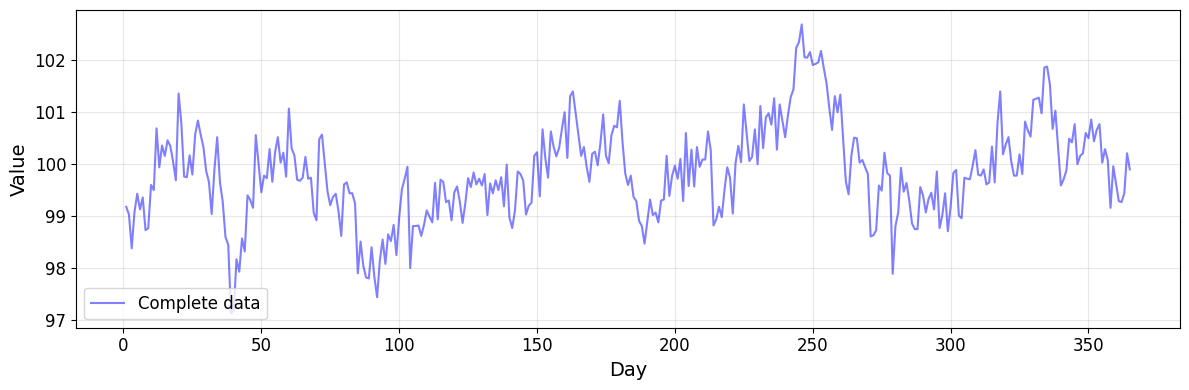

In [13]:
plot_time_series(eload)

Just from look at the plot, there are arguably no obvious issue that would violate stationarity: there is no clear upward or downward trends, no outliers, no structural breaks, and the magnitude of fluctuations &mdash; in very simple terms, the wiggle of the time series looks more or less the same everywhere. Although visual inspection alone cannot establish stationarity, it provides a quick and intuitive way to identify potential problems before applying more formal statistical tests.

To give an example, without going into the inner workings here, let's consider the **Augmented Dickey–Fuller (ADF) test**. This statistical test is used to assess whether a time series contains a unit root, which is an important form of non-stationarity. Its null hypothesis $H_0$ states that the series has a unit root and is therefore non-stationary, while the alternative hypothesis $H_1$ indicates stationarity (around the deterministic terms included in the test). A small p-value, commonly $p<0.05$, provides evidence to reject the null hypothesis and supports stationarity; a larger p-value means that there is insufficient evidence to reject the presence of a unit root, but does *not* by itself prove that the series is non-stationary.

In the code cell below, we apply the [`adfuller()`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html#statsmodels.tsa.stattools.adfuller) method of [statsmodels](https://www.statsmodels.org/stable/index.html) library to perform ADF test on our time series. It returns, among other values, the ADF test statistic, p-value, and critical values, which can be used to assess whether the null hypothesis of a unit root can be rejected. In the example below, we only print the result p-value to keep it simple.

In [14]:
result = adfuller(eload)

print(f"ADF test: p-value = {result[1]:.3f}")

ADF test: p-value = 0.001


A p-value of approximately $0.001$ in an ADF test provides strong evidence against the null hypothesis that the time series contains a unit root. Since $0.001$ is well below common significance levels such as $0.05$ or even $0.01$, the null hypothesis is rejected, supporting the conclusion that the series is stationary with respect to the unit-root behavior tested by the ADF test. However, keep in mind that this does *not* prove that every stationarity assumption is satisfied; the ADF test specifically tests for a unit root. Visual inspection and other diagnostics can still reveal issues such as structural breaks or changing variance.

Let's therefore consider another test: the **Kwiatkowski–Phillips–Schmidt–Shin (KPSS) test**. This is also used to assess whether a time series is stationary around a constant or deterministic trend. Unlike the ADF test, its null hypothesis $H_0$ states that the series is stationary, while the alternative $H_1$ indicates non-stationarity; therefore, a small p-value provides evidence to reject stationarity, whereas a larger p-value means there is insufficient evidence to reject the stationarity assumption. This makes the KPSS test a useful complement to the ADF test because the two tests approach stationarity from opposite null hypotheses.

Again, we use an existing implementation provided by the [statsmodels](https://www.statsmodels.org/stable/index.html) library. The `kpss()` method from performs the KPSS test** for stationarity and returns the p-value (among other values), which can be used to assess whether the null hypothesis of stationarity should be rejected.

In [15]:
result = kpss(eload)

print(f"KPSS test: p-value = {result[1]:.3f}")

KPSS test: p-value = 0.021


A KPSS p-value of approximately $0.02$ provides evidence against the null hypothesis that the time series is stationary. At the commonly used $5\%$ significance level, $0.02 < 0.05$, so we would reject $H_0$ and conclude that the series shows evidence of non-stationarity. This is the opposite interpretation of the ADF test: for KPSS, a small p-value is evidence against stationarity.

In short, for our example series, we get conflicting results showing that such statistical tests are never fool-proof. Remember that we generated this time series using an $\text{AR}(3)$ model with appropriate coefficients (i.e., the coefficients satisfy the stability condition). This means that the underlying process is indeed stationary. However, stationarity tests such as KPSS operate on only a **finite realization** of that process and can occasionally give misleading results due to random sampling variation. This is especially likely for highly persistent AR processes, where shocks decay slowly and a finite sample may visually resemble a non-stationary series.

Therefore, a KPSS p-value of $0.02$ does not necessarily mean that the underlying $\text{AR}(3)$ process is truly non-stationary; it means that the KPSS test found evidence against stationarity in that particular sample. In practice, stationarity should therefore be assessed using multiple sources of evidence, such as visual inspection, KPSS, ADF, and tests (e.g., Phillips–Perron test, Zivot–Andrews test), rather than relying on a single statistical test.

Another common approach to better understand the nature of a time series is by means of **Autocorrelation Function (ACF) plot**. An ACF plot shows the correlation between a time series and **lagged versions of itself**. For each lag $k$, it plots $\rho(k)=\text{Corr}(x_t,x_{t-k})$, i.e., the correlation between all available observation pairs separated by k time steps. For example, for daily observations:

* **Lag 1:** correlation between observations one day apart
* **Lag 2:** correlation between observations two days apart
* **Lag 7:** correlation between observations one week apart
* ...

Each vertical bar represents the estimated autocorrelation at that lag. A value near (+1) means observations separated by that lag tend to move together, a value near $-1$ means they tend to move in opposite directions, and a value near $0$ means little linear association. Lag 0 is always $1$, since every series is perfectly correlated with itself. With this in mind, let's plot and inspect the ACF plot for the first $20$ lags for our example time series; we provide the auxiliary method `plot_acf_results()` for that.

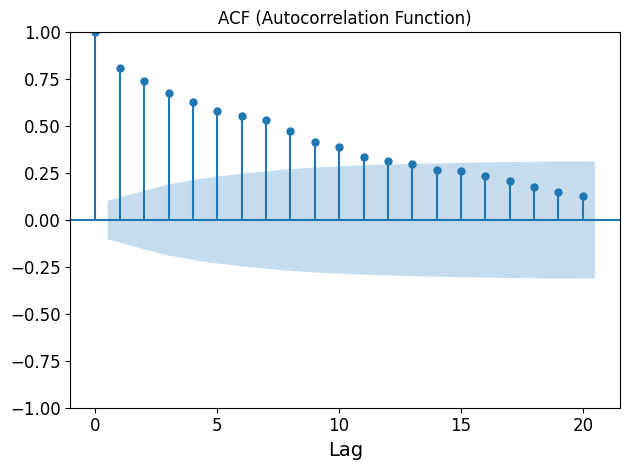

In [16]:
plot_acf_results(eload, lags=20)

The ACF plot shows mostly positive autocorrelation (particularly for early lags) that gradually decreases as the lag increases, indicating that observations close together in time tend to have similar values and that this relationship becomes weaker for observations further apart. This pattern suggests that the time series has a certain degree of **persistence**, meaning that the effect of past observations or shocks gradually fades over time rather than disappearing immediately. A steadily decaying ACF is also characteristic of many **stationary autoregressive processes** and therefore supports the idea that an AR model may be appropriate, provided that the correlations eventually approach zero.

One important detail is that the ACF measures the **total correlation** between two observations. For example, $y_t$ may be correlated with $x_{t-3}$ even if there is no direct lag-3 effect, because the relationship can propagate indirectly through $x_{t-1}$ and $x_{t-2}$. A better way to isolate the direct distribution of individual lags is therefore the **Partial Autocorrelation Function (PACF) plot**. In a nutshell, the PACF measures the direct relationship between observations $k$ time steps apart after removing the influence of all intermediate lags. For example, the PACF at lag 3 measures how strongly $x_t$) is related to $x_{t-3}$ after accounting for the relationships through $x_{t-1}$ and $x_{t-2}$. The PACF plot then shows this **direct correlation** for each lag and is therefore particularly useful for identifying the lag order of an AR model

We provide the auxiliary method `plot_pacf_results` to plot the PACF for, again, the first $20$ lags.

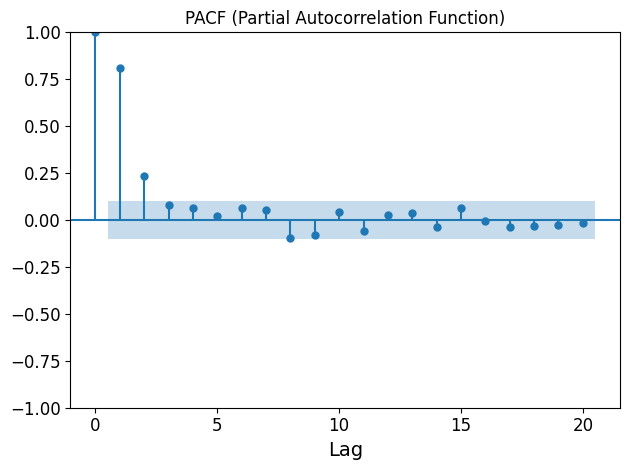

In [17]:
plot_pacf_results(eload, lags=20)

The shaded region in a PACF plot represents an approximate **confidence interval around zero**, commonly a $95\%$ confidence interval under the assumption that the true partial autocorrelation at that lag is zero. A lag whose PACF bar remains inside the shaded region is therefore not statistically distinguishable from zero, meaning there is little evidence of a direct relationship at that lag. A bar that extends outside the shaded region suggests a statistically significant partial autocorrelation and therefore evidence that the lag provides additional direct information about the current observation after accounting for the shorter lags.

For AR model selection, this is useful because an $\text{AR}(p)$ process *theoretically* has non-zero PACF values up to lag $p$ and zero values afterward. Since we generated our time series synthetically using an $\text{AR}(3)$ model, we would expect the first $3$ lags to be outside the confidence interval. However, only the first $2$ lags are clearly outside; and lag 8 arguably a little bit. However, this is not surprising. Firstly, the coefficient $\phi_3$ of the $\text{AR}(3)$ model generating the time series was rather small with $\phi_3 = 0.05$. And secondly, the time series is, again, only a finite realization of this process and contains the randomly sampled variations.

In practice, based on this result we might initially favor a lag order of $p = 2$. However, by default, we first consider $p = 3$ (in line with the $\text{AR}(3)$ model that generated the data); but we do consider other values for $p$ later on as well. As part of our analysis, we also want to explore the forecast capabilities of fitted $\text{AR}(p)$. To this end, we define a forecast horizon of, by default, $31$ observations (i.e., one month for our example). This means that we use the first $11$ months for training and the last month for validation. As usual, you can change both values to see their effects on the results.

In [18]:
p_eload = 3              # Default lag order p
forecast_horizon = 31    # Default forecast horizon (#observations)

In summary, the EDA told us that our time series has (mostly) likely all the required characteristics required to fit an $\text{AR}(p)$ (mainly: stationarity, no structural breaks, no outliers, no trends). We also got some first idea what is likely to constitute a meaningful value for lag order $p$. With that, we can not fit and assess different models. First, we briefly mirror our "manual approach" of using the OLS approach and a Linear Regression implementation, mirroring our previous toy example (see above). Then, we use an existing implementation for some deeper exploration.

### "Manual Approach" using OLS

Mimicking our toy example, we first need to create the target vector $\mathbf{y}$ by removing the first $p$ observation from the original time series; recall that we can only start making predictions from observation $x_{p+1}$ onward since we always need $p$ existing observations as the lag features.

In [19]:
y_eload = eload[p_eload:]

The create lagged feature matrix $\mathbf{X}$, we call once more our method `convert_to_lag_features()`; we saw how this method works in the toy example.

In [20]:
X_eload = convert_to_lag_features(eload, p=p_eload)

print(f"Shape of feature matrix: {X_eload.shape}")

Shape of feature matrix: (362, 3)


Notice again that the matrix has $n - p$ (by default, $365 - 3 = 362$) since we cannot make predictions for the first $p$ observations. Lastly, we split both the feature matrix and target vector with respect to the forecast horizon into a training and test set. 

**Important:** When splitting a time series into training and test sets, the temporal order of observations must be preserved because observations are not independent and future values may depend on past values. A random split could place future observations in the training set while earlier observations appear in the test set, causing data leakage and producing an unrealistic estimate of forecasting performance. Therefore, the model should typically be trained on an earlier continuous period and evaluated on a later period, reflecting how forecasting works in practice.

In [21]:
X_eload_train, X_eload_test = X_eload[:-forecast_horizon], X_eload[-forecast_horizon:]
y_eload_train, y_eload_test = y_eload[:-forecast_horizon], y_eload[-forecast_horizon:]

print(f"Shape of training data: {X_eload_train.shape}")
print(f"Shape of test data:     {X_eload_test.shape}")

Shape of training data: (331, 3)
Shape of test data:     (31, 3)


Using once more the [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) implementation provided by the [scikit-learn](https://scikit-learn.org/) library, we can fit a $\text{AR}(3)$ give our feature matrix and target vector; using only the training data, of course.

In [22]:
eload_linreg = LinearRegression().fit(X_eload_train, y_eload_train)

Because we know for our time series the true coefficients of the $\text{AR}(3)$ that generated the time series ($\phi_1 = 0.6$, $\phi_2 = 0.2$, and $\phi_3 = 0.05$), we can compare them with the coefficients estimated by the Logistic Regression model. Like before, we can easily access the estimated coefficients as attributes of the model implementation.

In [23]:
print(f'Coefficients: {", ".join( f"phi{i+1} = {coef:.4f}" for i, coef in enumerate(eload_linreg.coef_))}')

Coefficients: phi1 = 0.5932, phi2 = 0.1875, phi3 = 0.0942


Overall, the estimated coefficients are arguably close to the true coefficients, although the model puts more emphasis on past observations; notice that the estimated coefficients of lag 1 and 2 are lower than the true coefficient, while the estimated coefficient for lag 3 is larger than the true coefficient. Let's also look at estimated intercept $\hat{c}$:

In [24]:
print(f'Bias: c = {eload_linreg.intercept_:.4f}')

Bias: c = 12.4950


To get a good sense if this estimate is plausible, recall that we could compute the long-run mean of a time series as:

$$\large
\mu = \frac{c}{1 - \sum_{i=1}^p \phi_i }
$$

This means that we can compute the true bias $c$ as:

$$\large
c=\mu\left(1-\sum_{i=1}^p\phi_i\right)
$$

If we plug in the true values for the mean ($\mu = 100$) and the true coefficients ($\phi_1 = 0.6$, $\phi_2 = 0.2$, and $\phi_3 = 0.05$), we get:

$$
\begin{align}
\large c\ &\large=\mu\left(1-\sum_{i=1}^p\phi_i\right)\\[0.5em]
&\large= 100 (1- (0.65 + 0.2 + 0.05))\\[0.5em]
&\large= 100 (1- 0.9)\\[0.5em]
&\large= 10\\[0.5em]
\end{align}
$$

So our fitted intercept of $\hat{c} = 12.49$ is actually fairly close to the true intercept of $c = 10$. However, if we now use the fitted intercept $c$ and the fitted coefficients $\phi_i$, we get the following estimate for the mean:

$$
\begin{align}
\large \hat{\mu}\ &\large= \frac{\hat{c}}{1 - \sum_{i=1}^p \hat{\phi}_i }\\[0.5em]
&\large= \frac{12.495}{1 −(0.5932 + 0.1875 + 0.0492)}\\[0.75em]
&\large= \frac{12.495}{1 - 0.83}\\[0.5em]
&\large= 73.46
\end{align}
$$

The larger discrepancy between the true mean of $\mu = 100$ and in the fitted mean $\hat{\mu} = 73.46$, mainly comes from the fitted AR coefficients.is very sensitive to the coefficient sum when it is close to 1 &mdash; which it is with $0.9$ for the true coefficients and $0.83$ for the estimated coefficients. So the main issue is not that the intercept was estimated badly. Rather, relatively small estimation errors in the AR coefficients can produce a large error in the implied long-run mean because your process is fairly persistent, with $\sum\phi_i=0.9$. With only around 365 observations, this kind of deviation is quite plausible. Increasing the sample size would generally make the fitted coefficients, and therefore the implied mean, closer to their true values.

Lastly, we can explore the forecast performance of our fitted model. To do so, we use the method `forecast_linreg()` we have seen before, and pass the observations for the first $11$ months to predict the next $31$ days. We can then use the method `plot_time_series` to plot the result.

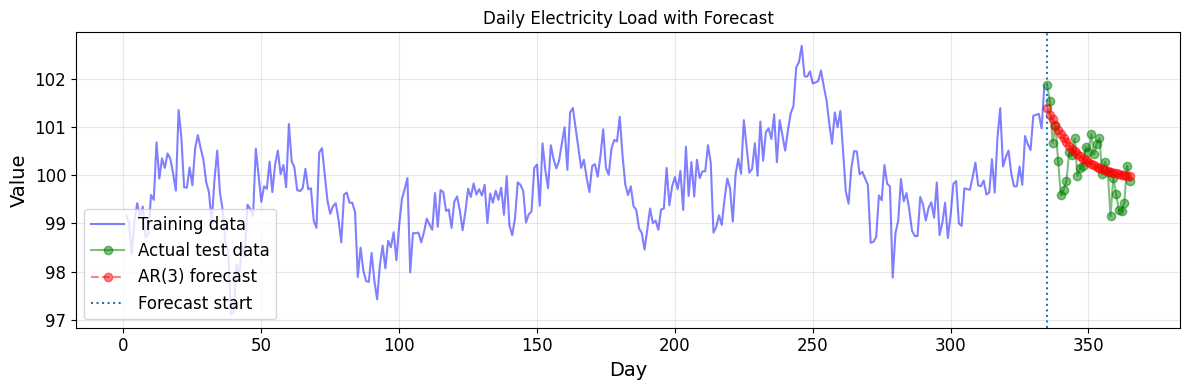

In [25]:
forecast_ols = forecast_linreg(y_eload_train, eload_linreg, p=p_eload, steps=forecast_horizon)

plot_time_series(eload, model_name='AR', order=p_eload, forecast=forecast_ols, title="Daily Electricity Load with Forecast")

Forecast values produced by an AR model generally do not exactly match the true future observations because a time series consists of both a **predictable component**, determined by previous observations, and an **unpredictable innovation or shock**. An AR model can forecast the systematic component based on the observed history, but future innovations are unknown and, by definition, cannot be predicted. Moreover, for multi-step forecasts (e.g., several days into the future for our example), this uncertainty accumulates and the influence of the currently observed values gradually decreases, causing forecasts from a stationary AR model to move toward its long-run mean.

In practice, AR models should therefore not be expected to predict the exact future trajectory of a time series. They are most useful for estimating the **expected future behavior**, particularly over shorter horizons where recent observations still contain meaningful predictive information. Their practical value should be assessed by whether they provide more accurate forecasts than simple benchmarks, such as predicting the historical mean or the most recent observation, rather than by expecting individual forecasts to perfectly match the realized future values.

When evaluating different values of lag order $p$ and the forecast horizon (e.g., more or less than $31$ days), it is typically not useful to compare the different result plots. However, we can use the true "future" observations and the estimated observations predicted by the model by quantifying their difference. This is typically done using the **Root Mean Squared Error (RSME)**. Using an existing built-in method of the [scikit-learn](https://scikit-learn.org/), we get:

In [26]:
rmse = root_mean_squared_error(y_eload_test, forecast_ols)

print(f"RMSE: {rmse:.3f}")

RMSE: 0.523


This value alone is not very meaningful since we typically compare multiple values from models with different lag orders and/or forecast horizons &mdash; which we explore next using existing implementations of AR models for convenience and a cleaner code.

### Practical Approach

While fitting a $\text{AR}(p)$ "manually" using the OLS method with a Linear Regression generally works just fine, in practice, we typically favor mature implementation of fitting methods for AR models. Thus, in the following with use the [`AutoReg`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AutoReg.html) class of the [statsmodels](https://www.statsmodels.org/stable/index.html) library. This class estimates autoregressive models using **conditional maximum likelihood (MLE)**: the first (p) observations are treated as given, and the remaining observations are modeled from their lagged values. However, under the additional assumption of **Gaussian innovations**, i.e., $\varepsilon_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma^2)$, maximizing the conditional likelihood with respect to the AR coefficients is mathematically equivalent to minimizing the sum of squared residuals, so conditional MLE and OLS produce the same coefficient estimates &mdash; as we will see.

Compared to our "manual approach" above, the [`AutoReg`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AutoReg.html) class provides a more convenient interface to train an $\text{AR}(p)$ model. For example, it automatically handles the special consideration of the first $p$ observations. Thus, we can split our training set directly with respect to the time horizon; see the code cell below.

In [27]:
eload_train, eload_test = eload[:-forecast_horizon], eload[-forecast_horizon:]

After passing the training part of our time series and the lag order $p$ of choice &mdash; among other arguments we ignore here for simplicity &mdash; we can train the $\text{AR}(p)$ model by calling the `fit()` method of the [`AutoReg`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AutoReg.html) class. The class also provides a `forecast()` method, to forecast a specified number of observations. With these predicted values we can again compute the RSME.

To illustrate this process, the code cell below fits multiple $\text{AR}(p)$ with different lag orders, and uses each model to forecast the same number of observations, and compute the respective RSMEs. Apart from the RSME the [`AutoReg`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AutoReg.html) also computes various internal evaluation metrics when fitting a model. For example, The **Bayesian Information Criterion (BIC)** is a model-selection metric that balances how well a fitted AR model explains the training data against the number of parameters it uses. It penalizes unnecessarily large lag orders, helping to avoid overfitting. When comparing several $\text{AR}(p)$ models fitted to the same data, a lower BIC is preferred; note that the absolute BIC value has little meaning by itself, so it is primarily the difference between candidate models that matters.

In [28]:
for p in range(1, 6):
    model = AutoReg(eload_train, lags=p).fit()
    forecast = model.forecast(steps=forecast_horizon)
    rmse = root_mean_squared_error(eload_test, forecast)
    print(f"[p={p}]: BIC={model.bic:.4f}, RSME={rmse:.4f}")

[p=1]: BIC=549.4368, RSME=0.4988
[p=2]: BIC=534.1137, RSME=0.4994
[p=3]: BIC=534.0744, RSME=0.5226
[p=4]: BIC=537.0558, RSME=0.5528
[p=5]: BIC=541.6224, RSME=0.5649


Notice how the result favors different values for $p$. This is not contradictory because BIC and RMSE measure different things. A lowest BIC at $p=3$ indicates that $\text{AR}(3)$ provides the best balance between explaining the observed training data and model complexity. In other words, there is evidence that lags 2 and 3 contain meaningful information about the underlying time-series structure. A lowest forecast RMSE at $p=1$, however, means that $\text{AR}(1)$ happened to predict the evaluated future observations more accurately.

This can occur because out-of-sample RMSE is affected by random future innovations and estimation uncertainty, especially when the validation/test period is short. The simpler $\text{AR}(1)$ model may have lower estimation variance and may, by chance, align better with that particular future realization even though $\text{AR}(3)$ better represents the underlying process. Therefore, if your objective is **understanding or identifying the AR structure**, the BIC result supports $p=3$; if your objective is **forecasting**, you should prefer the model with the lowest RMSE only when that result is stable across many out-of-sample forecasts &mdash; at least with this approach to assess a model's forecast performance; we see a common alternative in a moment.

**Important:** Keep in mind that this simple comparison of different $p$ values is not the proper way to perform model selection since we use the test set to identify the best choice of $p$. In practice, we would need to further split the current training set into a training and validation set (ideally using cross-validation) to find $p$, and lastly evaluate the final model using the test set.

To see what other kind of information we get from a trained [`AutoReg`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AutoReg.html) model, let's first train model with $p=3$ and predict the observations for our forecast horizon.

In [29]:
model = AutoReg(eload_train, lags=p_eload).fit()
forecast = model.forecast(steps=forecast_horizon)

First, we look at the model itself. The `summary()` method of a fitted [`AutoReg`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AutoReg.html) model model produces a compact statistical overview of the estimated AR model. It reports information such as the estimated intercept and lag coefficients, their standard errors, test statistics, p-values, and confidence intervals, as well as model-level measures such as the log-likelihood, AIC, BIC, and HQIC. The summary is therefore useful for inspecting the fitted parameters, assessing their statistical significance, and comparing alternative AR model specifications.

In [30]:
print(model.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  334
Model:                     AutoReg(3)   Log Likelihood                -252.532
Method:               Conditional MLE   S.D. of innovations              0.519
Date:                Tue, 25 Aug 2026   AIC                            515.064
Time:                        18:12:53   BIC                            534.074
Sample:                             3   HQIC                           522.646
                                  334                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.4950      3.372      3.706      0.000       5.886      19.104
y.L1           0.5932      0.055     10.822      0.000       0.486       0.701
y.L2           0.1875      0.063      2.973      0.0

When looking at the this output, we can find the BIC value as before, as well as the estimated intercept $\hat{c}$ (`const`) and our $p=3$ estimated coefficients (`y.L1`, `y_L2`, and `y_L3`). If you compare them with the ones we got using the "manual OLS" method, you will see that they are all identical, as expected. This naturally also means that we get the same plot when visualizing the predicted observations of the forecast.

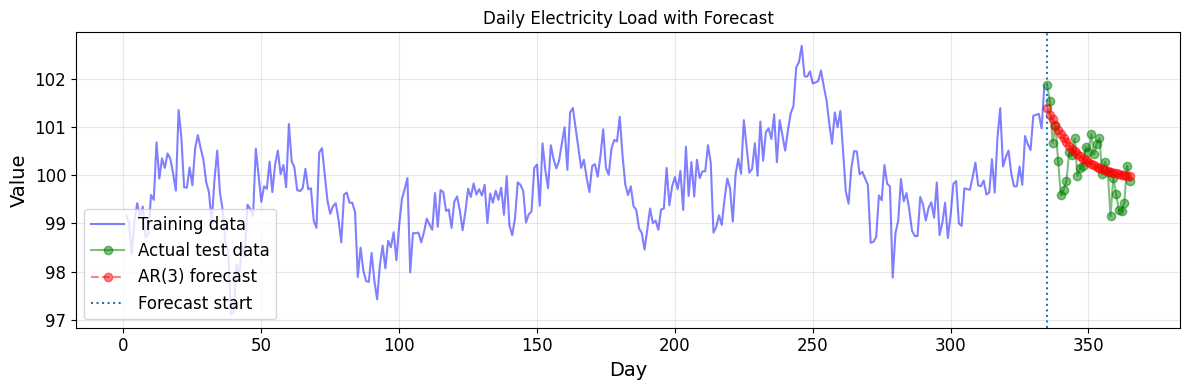

In [31]:
plot_time_series(eload, model_name='AR', order=p_eload, forecast=forecast, title="Daily Electricity Load with Forecast")

Evaluating an AR model by computing the RMSE over a single fixed forecast horizon can give an unreliable impression of forecasting performance because the result depends strongly on the particular future observations and therefore the random innovations—that happen to occur in that period. A common alternative is the so-called **walk-forward validation** which is a more robust alternative by repeatedly forecasting the next observation using only the data available at that point in time and then moving forward through the series. This produces many realistic out-of-sample forecasts, making the resulting RMSE less dependent on one particular forecast period and more representative of the model's typical forecasting performance.

Walk-forward validation evaluates a time-series model by repeatedly training it on all observations available up to a certain point, forecasting the next observation, and then adding the actual observed value to the training history before repeating the process. In this way, the training window moves or expands forward through time, producing multiple realistic out-of-sample forecasts. The method `walk_forward_validation()` provides a simple implementation of this idea. It first determines the initial size of the time series used for training the first model, i.e., the time step $t$ until we use the observations for the training. Starting with the initial training set, the method trains an $\text{AR}(p)$ model and predicts the single next observation. The method then increases $t$ by $1$ and repeats both steps: training an $\text{AR}(p)$ model and predict the next observation

Since each iteration gives a predicted value and its corresponding true value, we can again compute and return the RSME.

In [32]:
def walk_forward_validation(data, p=1, validation=0.2):
    # Ensure that time series is a NumPy array; convert a Python list if needed
    data = np.asarray(data, dtype=float)

    # Compute where the validation should being
    validation_size  = max(1, int(validation * len(data)))
    validation_start = len(data) - validation_size

    # Initialize lists for prediction and true values
    predictions, actual = [], []

    # Perform walk-forward validation 
    for t in range(validation_start, len(data)):

        # Everything observed before time t
        history = data[:t]

        # Fit AR(p) using statsmodels library with default arguments
        model = AutoReg(history, lags=p).fit()

        # One-step-ahead forecast
        prediction = model.forecast(steps=1)[0]

        # Record preduction and actual value for current step
        predictions.append(prediction)
        actual.append(data[t])

    # Compute and return RMSE
    return root_mean_squared_error(actual, predictions)

Let's use this method to run walk-forward validation for multiple $\text{AR}(p)$ with different lag orders $p$. Notice that we pass only the training part of our original time series. Since we do not touch the test data, we perform proper model selection.

In [33]:
for p in range(1, 10):
    rmse = walk_forward_validation(eload_train, p=p)
    print(f"[p={p}]: RMSE = {rmse:.3f}")

[p=1]: RMSE = 0.549
[p=2]: RMSE = 0.541
[p=3]: RMSE = 0.539
[p=4]: RMSE = 0.538
[p=5]: RMSE = 0.539
[p=6]: RMSE = 0.533
[p=7]: RMSE = 0.531
[p=8]: RMSE = 0.537
[p=9]: RMSE = 0.537


This evaluation now favors $p=7$. This is quite plausible and illustrates why walk-forward validation is generally more reliable than evaluating one fixed forecast period. The earlier result favoring $\text{AR}(1)$ may have been specific to the particular future observations in that test window. Walk-forward validation evaluates many one-step-ahead forecasts, so an $\text{AR}(7)$ achieving the lowest RMSE suggests that, for this particular sample and validation procedure, using the previous seven observations gives the best average one-step forecasting performance.

However, this does not necessarily mean that the true process is $\text{AR}(7)$! Since our synthetic data were generated by an $\text{AR}(3)$ model, lags 4-7 have no true direct effect, but finite-sample randomness can make them appear useful and slightly improve the validation RMSE. Thus, the results answer different questions: BIC favoring $p=3$ supports $\text{AR}(7)$ as the underlying parsimonious model structure, while walk-forward RMSE favoring $p=7$ says $\text{AR}(7)$ *happened* to give the best one-step forecasts over that validation sample. If the RMSE difference between $\text{AR}(3)$ and $\text{AR}(7)$ is small &mdash; which it arguably is &mdash; $p=7$ is not strong evidence for seven true lags.

As a final consideration, after fitting an AR model, it is good practice to perform **residual diagnostics** to verify that the model has adequately captured the systematic temporal structure in the data. If the model is properly specified, the remaining residuals should behave approximately like **white noise**, with no meaningful autocorrelation or systematic patterns; otherwise, remaining structure may indicate an inappropriate lag order or that a basic AR model does not fully describe the time series.

Conveniently, the [`AutoReg`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AutoReg.html) class automatically computes all residuals for the observations in the training data. We can treat this sequence of residuals as a time series and use the auxiliary method `plot_time_series()` to plot the residuals.

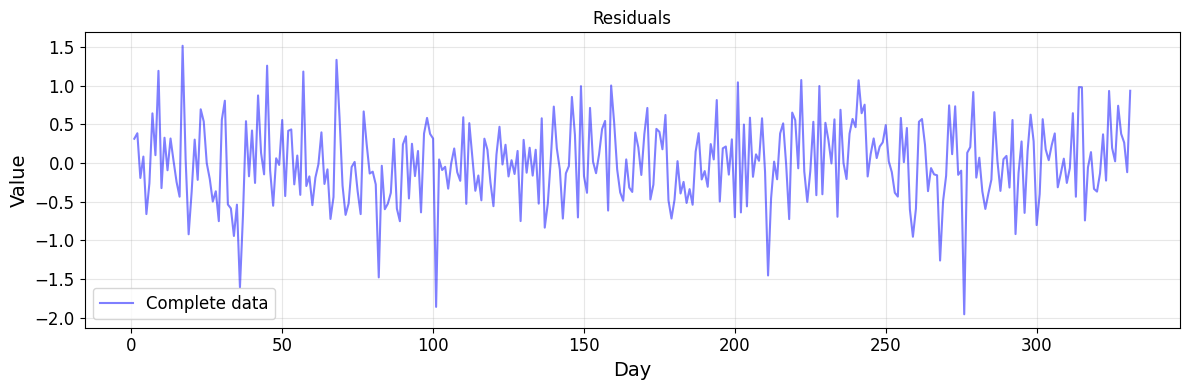

In [34]:
plot_time_series(model.resid, title="Residuals")

Using purely a visual inspection the residuals do look like random noise. Of course, this can be misleading, and we should therefore quantify this more appropriately. Residual diagnostics for an AR model typically focus on checking whether the remaining errors behave approximately like white noise, meaning that no systematic temporal structure remains unexplained by the model; common steps include:

* **Residual mean:** Compute the average of the residuals, which should be **close to zero**. A substantial non-zero mean indicates that the model systematically over- or underpredicts the observations.
* **PACF of residuals:** Plot the partial autocorrelations of the residuals. Ideally, the PACF values should be close to zero and mostly remain **inside the confidence bands**, indicating that no meaningful direct temporal dependencies remain.
* **Ljung-Box (LB) test:** Formally tests whether the residuals exhibit autocorrelation across a range of lags. The null hypothesis is that there is no residual autocorrelation, so a **large p-value** (commonly $p>0.05$) means there is insufficient evidence to reject the white-noise assumption, whereas a small p-value suggests that the model has left temporal structure unexplained.

For convenience, we provide the auxiliary method `residual_diagnostics()` which performs all these three steps and summarizes them into a single plot.

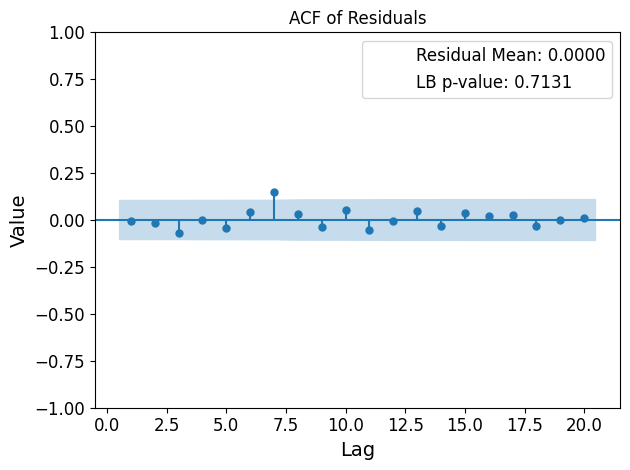

In [35]:
model = AutoReg(eload_train, lags=p_eload).fit()

residual_diagnostics(model, lags=20)

Unsurprisingly &mdash; after all, we synthetically generated our time series using a $\text{AR}(3)$ model &mdash; all results show that our fitted model is properly specified:

* the residual mean is, ignoring precision issues, basically $0$
* almost all PACF values are inside the confidence band
* the p-value of the LB test is large; $0.731 \geq 0.05$

### Discussion

As we just saw, properly fitting and evaluating an $\text{AR}(p)$ involves considerably more than simply selecting a lag order and estimating its coefficients. Before fitting the model, the underlying assumptions need to be considered, including stationarity, linear temporal dependence, regular sampling, sufficient observations, stability, and the behavior of the innovations. Model selection then requires careful consideration of the lag order and estimation method, while forecasting performance should be evaluated on unseen data using appropriate time-series validation techniques. Finally, residual diagnostics are important for checking whether the fitted model has adequately captured the temporal structure of the data.

These considerations become particularly important when working with **real-world time series**, which may contain trends, seasonality, missing observations, outliers, structural breaks, changing variance, or other characteristics that are absent from carefully constructed synthetic examples. The workflow presented in this notebook should therefore be regarded as an introduction rather than a comprehensive procedure. Additional stationarity tests, tests for structural breaks and other model assumptions, alternative model-selection and validation strategies, and more extensive residual diagnostics are available and may be required in practice.

Consequently, applying an AR model should be viewed as an **iterative modeling process**: inspect and understand the data, assess whether the model assumptions are reasonable, select and fit candidate models, evaluate their forecasting performance, diagnose the residuals, and revise the model when necessary. A fitted AR model should not be accepted solely because the estimation procedure succeeds; its assumptions, statistical properties, and performance should all be critically evaluated before its results are used for practical decision-making.

---

## Summary

Autoregressive (AR) models provide a conceptually simple and interpretable approach to time-series modeling by expressing each observation as a linear combination of previous observations and a random innovation. Despite this relatively simple mathematical formulation, properly fitting and evaluating an AR model is a nontrivial task in practice. Before fitting a model, the input time series should be carefully examined to determine whether the core AR assumptions are sufficiently satisfied, including stationarity, stable linear temporal dependence, regular sampling, sufficient observations, and appropriate innovation behavior. Selecting a suitable lag order and evaluating both forecasting performance and model residuals are equally important parts of the modeling process.

There are several methods for estimating AR models, including Ordinary Least Squares (OLS), Yule–Walker estimation, Burg's method, Maximum Likelihood Estimation, and Bayesian approaches. These methods differ in their objectives, computational requirements, statistical assumptions, and behavior for different sample sizes and model orders, meaning that no single estimation method is universally optimal. This notebook focuses primarily on OLS because of its simplicity and its close connection to standard Linear Regression: by transforming a time series into a set of lagged features, fitting an $\text{AR}(p)} model becomes a familiar Linear Regression problem.

Overall, AR modeling illustrates an important principle of time-series analysis: a simple model does not necessarily imply a simple modeling workflow! Reliable results require understanding the data, checking assumptions, selecting an appropriate model specification, evaluating forecasts on unseen observations, and verifying through residual diagnostics that the fitted model has captured the relevant temporal structure.